In [1]:
import random
import torch
import d2l

In [2]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [3]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 0.3291, -1.0574]) 
label: tensor([8.4426])


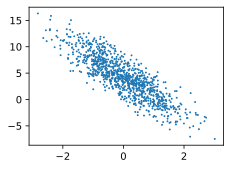

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)

In [5]:
batch_size = 10

for X, y in d2l.data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.3365, -0.8567],
        [ 1.8078, -0.6167],
        [ 1.2521,  0.6326],
        [-0.0141, -0.0706],
        [-0.4107, -0.5244],
        [ 1.2499,  0.3426],
        [-0.7319, -0.4709],
        [-0.9397,  1.2556],
        [-0.0597, -0.5734],
        [ 0.3057, -1.2261]]) 
 tensor([[ 6.4233],
        [ 9.9203],
        [ 4.5444],
        [ 4.4116],
        [ 5.1615],
        [ 5.5347],
        [ 4.3269],
        [-1.9512],
        [ 6.0296],
        [ 8.9873]])


In [6]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [7]:
lr = 0.03
num_epochs = 3
net = d2l.linreg
loss = d2l.squared_loss

for epoch in range(num_epochs):
    for X, y in d2l.data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        d2l.sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.038148
epoch 2, loss 0.000153
epoch 3, loss 0.000051


In [8]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差： {true_b - b}')

w的估计误差: tensor([-4.9853e-04, -3.8147e-06], grad_fn=<SubBackward0>)
b的估计误差： tensor([0.0003], grad_fn=<RsubBackward1>)
